# Trains YOLO26n-seg from scratch on the tooth instance-segmentation dataset (DATASET DIENTES), with targeted oversampling of the '3rd Molar' minority class. Generates article Table 9 (class distribution), Figure 2 (oversampling effect), Figure 3 (augmentation examples), and contributes one row to the cross-variant comparison table used for Table 10/11.

## CELL 1 — Set up the unit and copy the dataset into Colab

In [ ]:
import os, shutil
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

src = Path("/content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET DIENTES")
dst = Path("/content/dataset")

if not dst.exists():
    print("Copiando dataset...")
    shutil.copytree(src, dst)
    print("✅ Copia completada")

Mounted at /content/drive
Copiando dataset...
✅ Copia completada


## CELL 2 — Verify the dataset

In [ ]:
splits = ['train', 'valid', 'test']
for split in splits:
    imgs = list((dst / split / 'images').glob('*'))
    lbls = list((dst / split / 'labels').glob('*.txt'))
    print(f"{split}: {len(imgs)} imágenes | {len(lbls)} labels")

train: 1650 imágenes | 1750 labels
valid: 110 imágenes | 110 labels
test: 73 imágenes | 73 labels


## CELDA 3 — Identificar clases

In [ ]:
import glob

ids = set()
for f in glob.glob('/content/dataset/train/labels/*.txt'):
    for line in open(f):
        if line.strip():
            ids.add(int(line.split()[0]))

print(f"Total de clases: {len(ids)}")
print(f"IDs encontrados: {sorted(ids)}")

Total de clases: 8
IDs encontrados: [0, 1, 2, 3, 4, 5, 6, 7]


## CELL 4 — Configure data.yaml

In [ ]:
yaml_content = """names:
- 1st Molar
- 1st Premolar
- 2nd Molar
- 2nd Premolar
- 3rd Molar
- Canine
- Central Incisor
- Lateral Incisor
nc: 8
path: /content/dataset
test: test/images
train: train/images
val: valid/images
"""

with open('/content/dataset/data.yaml', 'w') as f:
    f.write(yaml_content)
print("✅ data.yaml actualizado")

names = ['1st Molar', '1st Premolar', '2nd Molar', '2nd Premolar',
         '3rd Molar', 'Canine', 'Central Incisor', 'Lateral Incisor']

✅ data.yaml actualizado


In [ ]:
from collections import Counter
import glob

labels = glob.glob('/content/dataset/train/labels/*.txt')
counter = Counter()
for f in labels:
    with open(f) as file:
        for line in file:
            class_id = line.split()[0]
            counter[class_id] += 1
print(counter)

Counter({'6': 4603, '7': 4491, '5': 4417, '1': 4093, '0': 3587, '3': 3576, '2': 2775, '4': 491})


## CELL 5 — Install the YOLO library


In [ ]:
# ⚠️ After running: Runtime Menu > Restart Session
!pip install ultralytics albumentations

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.2 MB/s eta 0:00:00


## CELL 5.5 — Oversampling with augmentation while preserving SEGMENTATION (polygons)

Just like in the nano pipeline: the minority class (3rd Molar) is balanced by generating augmented copies while preserving the polygons.

In [ ]:
import cv2
import numpy as np
import glob, os
import albumentations as A

transform = A.Compose([
    A.Rotate(limit=15, p=0.7),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.6),
    A.Affine(scale=(0.9, 1.1), p=0.5),
    A.GaussNoise(std_range=(0.02, 0.08), p=0.3),
], keypoint_params=A.KeypointParams(format='xy', remove_invisible=False))

labels_con_3er_molar = [f for f in glob.glob('/content/dataset/train/labels/*.txt')
                         if any(line.startswith('4 ') for line in open(f))]

print(f"Imágenes con 3rd Molar: {len(labels_con_3er_molar)}")

N_COPIAS = 5

for label_path in labels_con_3er_molar:
    img_path = label_path.replace('labels', 'images').replace('.txt', '.jpg')
    if not os.path.exists(img_path):
        continue
    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    poligonos = []
    clases = []
    with open(label_path) as f:
        for line_str in f:
            parts = line_str.strip().split()
            if not parts:
                continue
            cls_id = int(parts[0])
            coords = [float(p) for p in parts[1:]]
            puntos_norm = np.array(coords).reshape(-1, 2)
            puntos_px = puntos_norm * [w, h]
            poligonos.append(puntos_px)
            clases.append(cls_id)

    todos_los_puntos = np.vstack(poligonos)
    longitudes = [len(p) for p in poligonos]

    for i in range(N_COPIAS):
        try:
            aug = transform(image=img, keypoints=todos_los_puntos.tolist())
        except Exception as e:
            print(f"⚠️ Error en {img_path}: {e}")
            continue

        img_aug = aug['image']
        kpts_aug = np.array(aug['keypoints'])
        h_new, w_new = img_aug.shape[:2]

        nuevos_poligonos = []
        idx = 0
        for longitud in longitudes:
            poly = kpts_aug[idx:idx+longitud]
            idx += longitud
            poly_norm = poly / [w_new, h_new]
            poly_norm = np.clip(poly_norm, 0, 1)
            nuevos_poligonos.append(poly_norm)

        nuevo_nombre = os.path.basename(img_path).replace('.jpg', f'_aug3M_{i}.jpg')
        nueva_img_path = img_path.replace(os.path.basename(img_path), nuevo_nombre)
        nueva_label_path = nueva_img_path.replace('images', 'labels').replace('.jpg', '.txt')

        cv2.imwrite(nueva_img_path, img_aug)
        with open(nueva_label_path, 'w') as f:
            for cls, poly in zip(clases, nuevos_poligonos):
                coords_str = ' '.join(f"{x:.6f} {y:.6f}" for x, y in poly)
                f.write(f"{cls} {coords_str}\n")

print("✅ Oversampling con segmentación preservada — dataset balanceado listo")

ids = Counter()
for f in glob.glob('/content/dataset/train/labels/*.txt'):
    for line_str in open(f):
        if line_str.strip():
            ids[int(line_str.split()[0])] += 1
print(ids)

Imágenes con 3rd Molar: 338
✅ Oversampling con segmentación preservada — dataset balanceado listo
Counter({6: 8308, 7: 8156, 5: 8042, 1: 7368, 0: 6852, 3: 6151, 2: 5975, 4: 2856})


## CELL A — Comparative Chart of Class Distribution (for the article)

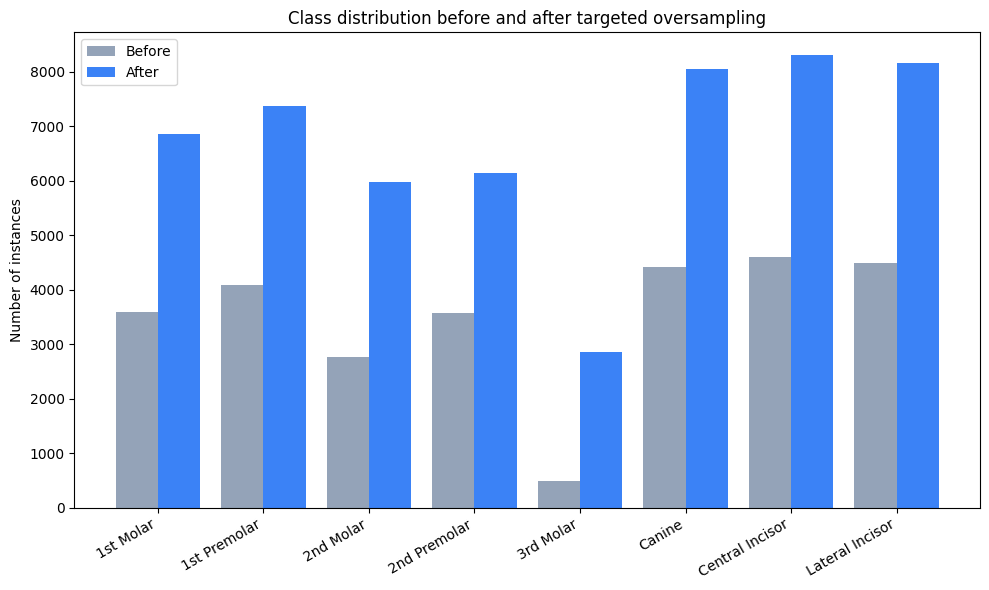

3rd Molar — Before: 491 | After: 2856


In [ ]:
import matplotlib.pyplot as plt
from collections import Counter
import glob

before_count = Counter()
for f in glob.glob('/content/dataset/train/labels/*.txt'):
    if '_aug3M_' in f:
        continue
    for line in open(f):
        if line.strip():
            before_count[int(line.split()[0])] += 1

after_count = Counter()
for f in glob.glob('/content/dataset/train/labels/*.txt'):
    for line in open(f):
        if line.strip():
            after_count[int(line.split()[0])] += 1

names_en = ['1st Molar', '1st Premolar', '2nd Molar', '2nd Premolar',
            '3rd Molar', 'Canine', 'Central Incisor', 'Lateral Incisor']

x = range(8)
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar([i - 0.2 for i in x], [before_count.get(i, 0) for i in x], width=0.4, label='Before', color='#94a3b8')
ax.bar([i + 0.2 for i in x], [after_count.get(i, 0) for i in x], width=0.4, label='After', color='#3b82f6')
ax.set_xticks(x)
ax.set_xticklabels(names_en, rotation=30, ha='right')
ax.set_ylabel('Number of instances')
ax.set_title('Class distribution before and after targeted oversampling')
ax.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/distribucion_clases_EN.png', dpi=200)
plt.show()

print(f"3rd Molar — Before: {before_count.get(4,0)} | After: {after_count.get(4,0)}")

## CELL B — View original image vs. enlarged versions with masks

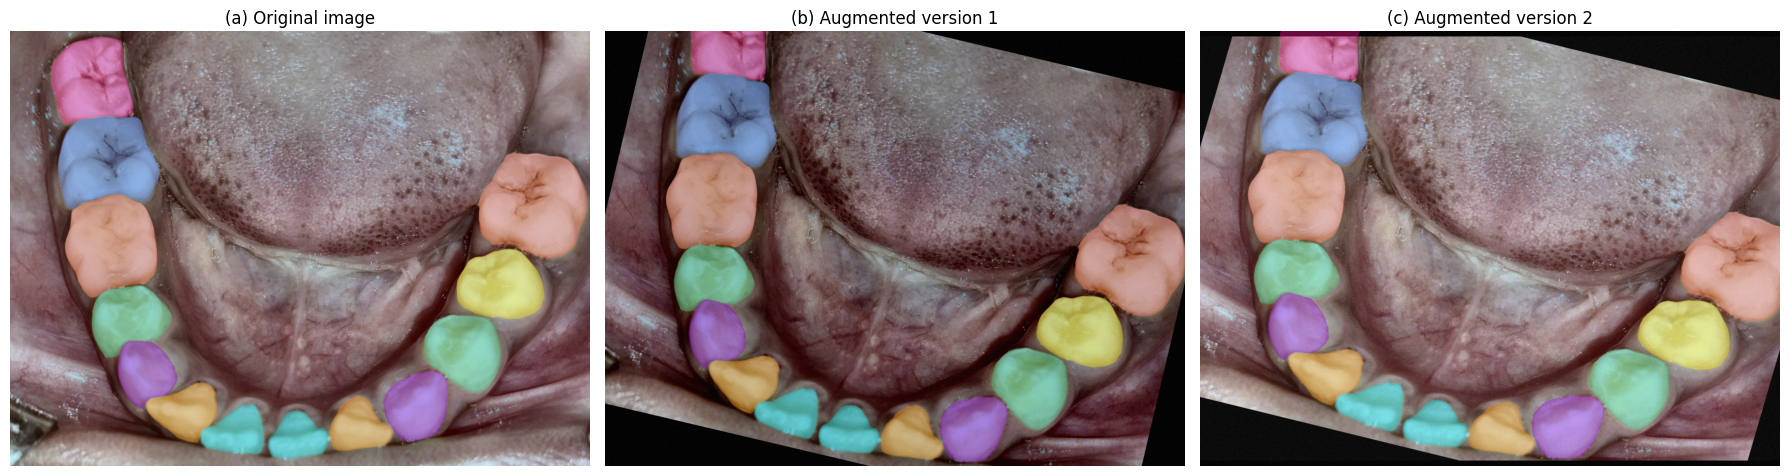

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def draw_polygons(img_path, label_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    overlay = img.copy()

    colors = {0:(255,99,71), 1:(60,179,113), 2:(65,105,225), 3:(255,215,0),
              4:(255,20,147), 5:(148,0,211), 6:(0,206,209), 7:(255,140,0)}

    with open(label_path) as f:
        for line in f:
            parts = line.split()
            cls = int(parts[0])
            coords = np.array(list(map(float, parts[1:]))).reshape(-1, 2)
            coords[:, 0] *= w
            coords[:, 1] *= h
            pts = coords.astype(np.int32)
            cv2.fillPoly(overlay, [pts], colors.get(cls, (200,200,200)))

    return cv2.addWeighted(img, 0.6, overlay, 0.4, 0)

original_example = labels_con_3er_molar[0]
original_img_path = original_example.replace('labels', 'images').replace('.txt', '.jpg')

base_name = os.path.basename(original_img_path).replace('.jpg', '')
aug_versions = [
    f'/content/dataset/train/images/{base_name}_aug3M_0.jpg',
    f'/content/dataset/train/images/{base_name}_aug3M_1.jpg',
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

img_orig = draw_polygons(original_img_path, original_example)
axes[0].imshow(img_orig)
axes[0].set_title('(a) Original image')
axes[0].axis('off')

for i, aug_path in enumerate(aug_versions):
    aug_label = aug_path.replace('images', 'labels').replace('.jpg', '.txt')
    if os.path.exists(aug_path):
        img_aug = draw_polygons(aug_path, aug_label)
        axes[i+1].imshow(img_aug)
        axes[i+1].set_title(f'({chr(98+i)}) Augmented version {i+1}')
        axes[i+1].axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/comparacion_augmentation_EN.png', dpi=200)
plt.show()

## CELL 6 — Training from Scratch | YOLO26m-seg with a Balanced Dataset

In [ ]:
from ultralytics import YOLO

model = YOLO('yolo26n-seg.yaml')

results = model.train(
    data='/content/dataset/data.yaml',
    epochs=150,
    imgsz=640,
    batch=8,
    pretrained=False,
    project='runs/dientes',
    name='yolo26n_dientes',
    patience=30,
    device='cuda:0',

    optimizer='AdamW',
    lr0=0.001,
    lrf=0.01,
    momentum=0.937,
    weight_decay=0.0005,

    fliplr=0.5,
    flipud=0.1,
    mosaic=1.0,
    mixup=0.1,
    degrees=10.0,
    translate=0.1,
    scale=0.5,
    shear=2.0,

    cos_lr=True,
    close_mosaic=15,
    val=True,
    verbose=True
)

# Get the actual save directory from the results object (avoids path mismatches between the requested 'name' and Ultralytics' actual save folder).
SAVE_DIR = results.save_dir
BEST_MODEL_PATH = SAVE_DIR / 'weights' / 'best.pt'
print(f"📁 Carpeta de resultados: {SAVE_DIR}")
print(f"🏆 Mejor modelo: {BEST_MODEL_PATH}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/dataset/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0

## CELL C — Training curves (loss, mAP50, precision, recall by epoch)

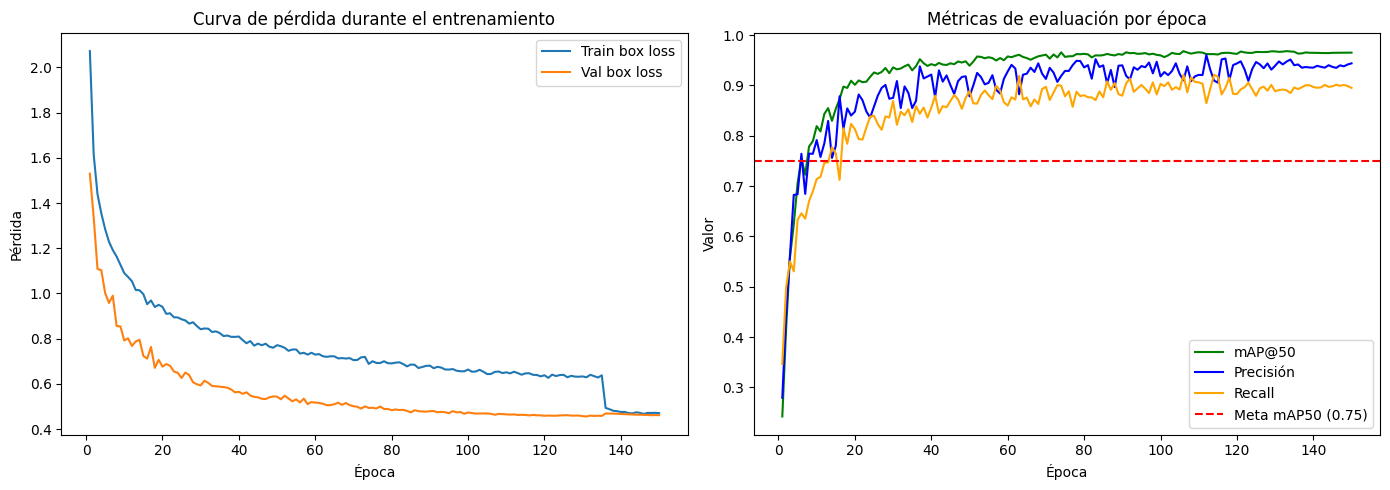

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results_csv = SAVE_DIR / 'results.csv'
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df['epoch'], df['train/box_loss'], label='Train box loss')
axes[0].plot(df['epoch'], df['val/box_loss'], label='Val box loss')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Pérdida')
axes[0].set_title('Curva de pérdida durante el entrenamiento')
axes[0].legend()

axes[1].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@50', color='green')
axes[1].plot(df['epoch'], df['metrics/precision(B)'], label='Precisión', color='blue')
axes[1].plot(df['epoch'], df['metrics/recall(B)'], label='Recall', color='orange')
axes[1].axhline(y=0.75, color='red', linestyle='--', label='Meta mAP50 (0.75)')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Valor')
axes[1].set_title('Métricas de evaluación por época')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/curvas_entrenamiento_n.png', dpi=200)
plt.show()

## CELL D — Metrics by class (table for the article)

In [ ]:
model = YOLO(BEST_MODEL_PATH)
metrics = model.val(data='/content/dataset/data.yaml', split='test')

print("📊 mAP50 por clase:\n")
tabla_resultados = []
for i, name in enumerate(names):
    ap50 = metrics.box.ap50[i] if i < len(metrics.box.ap50) else 0
    tabla_resultados.append({'Clase': name, 'mAP50': f"{ap50:.3f}"})
    print(f"  {name:20s}: {ap50:.3f}")

import pandas as pd
df_resultados = pd.DataFrame(tabla_resultados)
df_resultados.to_csv('/content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/mAP_por_clase_n.csv', index=False)
print("\n✅ Tabla guardada en Drive para pegar en el artículo")

Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n-seg summary (fused): 139 layers, 2,690,444 parameters, 0 gradients, 9.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 92.3±46.1 MB/s, size: 909.8 KB)
val: Scanning /content/dataset/test/labels... 73 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 73/73 277.5it/s 0.3s
val: New cache created: /content/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 2.2s/it 11.1s
                   all         73       1152      0.911      0.888      0.952      0.856      0.908      0.891      0.953      0.842
             1st Molar         63        139      0.938      0.866       0.95      0.852       0.93      0.863      0.952      0.861
          1st Premolar         73        174      0.919      0.918      0.969      0.884      0.919       0.92      0.967       0.8

## CELL 7 — Final evaluation of the test set

In [ ]:
metrics = model.val(
    data='/content/dataset/data.yaml',
    split='test'
)

print("\n📊 RESULTADOS EN TEST:")
print(f"  mAP@50:     {metrics.box.map50:.4f}  (meta: ≥ 0.75)")
print(f"  mAP@50-95:  {metrics.box.map:.4f}")
print(f"  Precisión:  {metrics.box.mp:.4f}   (meta: ≥ 0.80)")
print(f"  Recall:     {metrics.box.mr:.4f}   (meta: ≥ 0.70)")

if metrics.box.map50 >= 0.75:
    print("\n✅ META mAP@50 CUMPLIDA")
else:
    print(f"\n⚠️ mAP@50 = {metrics.box.map50:.4f} — debajo de la meta")

Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3313.6±1475.1 MB/s, size: 1284.5 KB)
val: Scanning /content/dataset/test/labels.cache... 73 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 73/73 34.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.9s/it 9.5s
                   all         73       1152      0.911      0.888      0.952      0.856      0.908      0.891      0.953      0.842
             1st Molar         63        139      0.938      0.866       0.95      0.852       0.93      0.863      0.952      0.861
          1st Premolar         73        174      0.919      0.918      0.969      0.884      0.919       0.92      0.967       0.87
             2nd Molar         51        104      0.927      0.849      0.938      0.838      0.927       0.85      0.941      0.842
 

## CELL 8 — Inference and Visualization Using Images from Drive

In [ ]:
from IPython.display import Image, display
import glob

test_imgs = [
    '/content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/IMAGENES PRUEBA/IMG1.jpeg',
    '/content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/IMAGENES PRUEBA/IMG2.jpeg'
]

results_pred = model.predict(
    source=test_imgs,
    save=True,
    project='runs/prueba',
    name='imagenes_prueba_n',
    conf=0.25,
    device='cuda:0'
)

print("🦷 Predicciones del modelo:\n")
pred_imgs = sorted(glob.glob('runs/prueba/imagenes_prueba_n/*'))
for img_path in pred_imgs:
    print(f"📸 {img_path.split('/')[-1]}")
    display(Image(img_path, width=700))


0: 448x640 2 1st Molars, 2 1st Premolars, 2 2nd Molars, 1 2nd Premolar, 1 3rd Molar, 6 Canines, 4 Central Incisors, 4 Lateral Incisors, 34.3ms
1: 448x640 2 1st Molars, 2 1st Premolars, 2 2nd Molars, 2 2nd Premolars, 2 Canines, 2 Central Incisors, 2 Lateral Incisors, 34.3ms
Speed: 3.1ms preprocess, 34.3ms inference, 12.2ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/segment/runs/prueba/imagenes_prueba_n
🦷 Predicciones del modelo:



## CELL 9 — Save best.pt to Drive (YOLO26m-sec)

In [ ]:
import shutil
from pathlib import Path

dst_dir = Path('/content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/MODELO DIENTES')
dst_dir.mkdir(parents=True, exist_ok=True)

shutil.copy(BEST_MODEL_PATH, dst_dir / 'yolo26n_dientes_best.pt')
shutil.copy(SAVE_DIR / 'confusion_matrix.png', dst_dir / f'confusion_matrix_n.png') \
    if (SAVE_DIR / 'confusion_matrix.png').exists() else None

print("✅ Modelo guardado en Drive:")
print(f"   {dst_dir / 'yolo26n_dientes_best.pt'}")

✅ Modelo guardado en Drive:
   /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/MODELO DIENTES/yolo26n_dientes_best.pt


## CELL E — Record results in a comparison table (nano / small / medium)

This cell adds a row to a CSV file shared on Drive, so that once you've finished running the three notebooks (n, s, m), you'll have a single comparison table ready for the article.

In [ ]:
import pandas as pd
from pathlib import Path

comp_path = Path('/content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/comparacion_modelos.csv')

n_params = sum(p.numel() for p in model.model.parameters())
size_mb = BEST_MODEL_PATH.stat().st_size / (1024 * 1024)

fila = {
    'modelo': 'YOLO26n-seg',
    'mAP50': round(float(metrics.box.map50), 4),
    'mAP50-95': round(float(metrics.box.map), 4),
    'precision': round(float(metrics.box.mp), 4),
    'recall': round(float(metrics.box.mr), 4),
    'parametros': n_params,
    'tamano_MB': round(size_mb, 2),
    'inferencia_ms': round(metrics.speed.get('inference', 0), 2),
}

if comp_path.exists():
    df_comp = pd.read_csv(comp_path)
    df_comp = df_comp[df_comp['modelo'] != fila['modelo']]  # evita duplicados si se re-corre
    df_comp = pd.concat([df_comp, pd.DataFrame([fila])], ignore_index=True)
else:
    df_comp = pd.DataFrame([fila])

df_comp.to_csv(comp_path, index=False)
print("✅ Fila añadida a la tabla comparativa:")
print(df_comp)

# NOTE: this cell appends/updates a row in a CSV shared across the three variant notebooks (n/s/m); run all three to get the full comparison.

✅ Fila añadida a la tabla comparativa:
        modelo   mAP50  mAP50-95  precision  recall  parametros  tamano_MB  \
0  YOLO26s-seg  0.9663    0.8900     0.9167  0.9262    10368436      22.29   
1  YOLO26n-seg  0.9523    0.8556     0.9115  0.8881     2690444       6.26   

   inferencia_ms  
0          26.21  
1          14.92  


### (Optional, run only after you have run n + s + m) — Final comparison chart

Run this cell once you have run the 3 notebooks (nano, small, medium): it will read `comparacion_modelos.csv` and generate the comparative bar chart for the article.

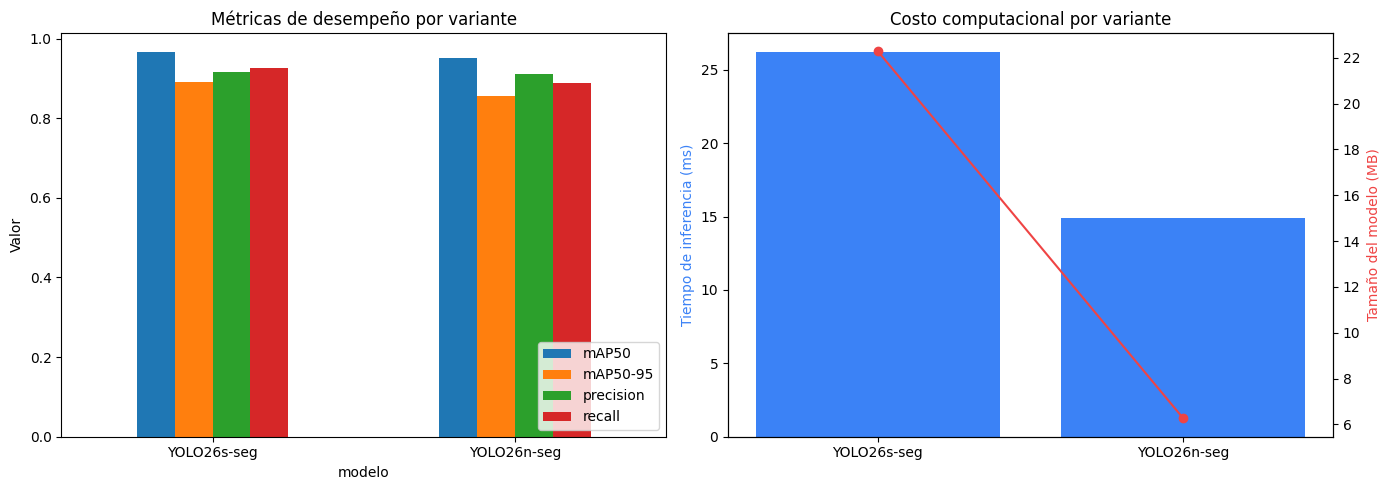

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df_comp = pd.read_csv('/content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/comparacion_modelos.csv')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_comp.plot(x='modelo', y=['mAP50', 'mAP50-95', 'precision', 'recall'], kind='bar', ax=axes[0])
axes[0].set_title('Métricas de desempeño por variante')
axes[0].set_ylabel('Valor')
axes[0].legend(loc='lower right')
axes[0].tick_params(axis='x', rotation=0)

ax2 = axes[1]
ax2.bar(df_comp['modelo'], df_comp['inferencia_ms'], color='#3b82f6')
ax2.set_ylabel('Tiempo de inferencia (ms)', color='#3b82f6')
ax2b = ax2.twinx()
ax2b.plot(df_comp['modelo'], df_comp['tamano_MB'], color='#ef4444', marker='o')
ax2b.set_ylabel('Tamaño del modelo (MB)', color='#ef4444')
axes[1].set_title('Costo computacional por variante')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/comparacion_final_modelos.png', dpi=200)
plt.show()